<h2 style='color:blue' align='center'>Data Augmentation To Address Overfitting In Flower Classification CNN</h2>

**In this notebook we will build a CNN to classify flower images. We will also see how our model overfits and how overfitting can be addressed using data augmentation. Data augmentation is a process of generating new training samples from current training dataset using transformations such as zoom, rotations, change in contrast etc**

https://www.youtube.com/watch?v=mTVf7BN7S8w&list=PLeo1K3hjS3uu7CxAacxVndI4bE_o3BDtO&index=26

Credits: I used tensorflow offical tutorial: https://www.tensorflow.org/tutorials/images/classification as a reference and made bunch of changes to make it simpler

In below image, 4 new training samples are generated from original sample using different transformations

<img src="daisy2.JPG" />

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL  # This is python Image Library
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [55]:
#pip install opencv-python
#This is to import cv2

In [56]:
import PIL

> Below We will download flowers dataset from google website and store it locally. In below call it downloads the zip file (.tgz) in cache_dir which is . meaning the current folder

<h3 style='color:purple'>Load flowers dataset</h3>

In [57]:
# this is Google path
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir="Users\prabh\DS Project Toolkit\DL\17_data_augmentation", untar=True)

# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

In [58]:
data_dir

# It should give path like this, here not working:  c\Users\prabh\DS Project Toolkit\DL\17_data_augmentation
# Giving this path C:\tmp\.keras\datasets\flower_photos

'/tmp\\.keras\\datasets\\flower_photos'

In [59]:
import pathlib
# This pathlib helpful to read all these images as Numby array. This will be same as original path just will be windows path

data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('/tmp/.keras/datasets/flower_photos')

In [60]:
list(data_dir.glob('*/*.jpg'))[:5]  # glob gives 1st 5 images which has extension .jpg

[WindowsPath('/tmp/.keras/datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [61]:
image_count = len(list(data_dir.glob('*/*.jpg'))) # This gives all image count
print(image_count)

3670


In [62]:
roses = list(data_dir.glob('roses/*'))  # This gives ll images in rose folder
roses[:5]

[WindowsPath('/tmp/.keras/datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

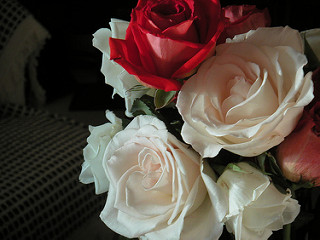

In [63]:
PIL.Image.open(str(roses[1])) # This  prints 2nd image in rose folder

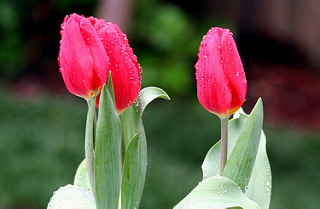

In [64]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

<h3 style='color:purple'>Read flowers images from disk into numpy array using opencv</h3>

In [65]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [66]:
# Here we are giving class name/label to each image folder
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [67]:
flowers_images_dict['roses'][:5]

[WindowsPath('/tmp/.keras/datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('/tmp/.keras/datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [68]:
str(flowers_images_dict['roses'][0])
#FILE PATH OF 1ST IMAGE IN ROSE FOLDER

'\\tmp\\.keras\\datasets\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [69]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))
#Here img is 1 Rose image

In [70]:
img.shape
#Each image is 3-D array and here 3 is RGB

(240, 179, 3)

In [71]:
cv2.resize(img,(180,180)).shape  # images were of diff sizes so we need to resize into same size. 

(180, 180, 3)

In [72]:
X, y = [], []

# Here we are labeling each image based on its folder/key value from dictionary "flowers_images_dict"
# Then we are resizing each image into (180,180) and appending each image to X variable and each label to y

for flower_name, images in flowers_images_dict.items():
    print(flower_name)
   # print(images)
    # Here we are reading each flower from each folder one by one: Here flower_name is hardcoded key value in dict
    # Here images is 1 folder all images
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        # Here we are appending foldername which are saved as integer value as class/Lable value
        y.append(flowers_labels_dict[flower_name])

roses
daisy
dandelion
sunflowers
tulips


In [73]:
X = np.array(X)
y = np.array(y)

X[0:1]

array([[[[ 1, 16,  7],
         [ 1, 16,  7],
         [ 1, 17,  9],
         ...,
         [23, 50, 31],
         [25, 51, 32],
         [26, 52, 33]],

        [[10, 23, 15],
         [10, 23, 15],
         [ 9, 22, 14],
         ...,
         [20, 44, 30],
         [23, 47, 33],
         [26, 50, 36]],

        [[13, 20, 13],
         [12, 20, 13],
         [11, 19, 12],
         ...,
         [21, 43, 30],
         [22, 45, 31],
         [25, 48, 34]],

        ...,

        [[12, 24, 18],
         [11, 22, 15],
         [12, 21, 11],
         ...,
         [ 7, 14,  7],
         [ 2,  8,  2],
         [ 0,  2,  0]],

        [[19, 30, 28],
         [16, 26, 21],
         [14, 22, 15],
         ...,
         [ 3, 12,  2],
         [ 0,  8,  1],
         [ 0,  6,  1]],

        [[11, 21, 20],
         [17, 25, 24],
         [21, 28, 23],
         ...,
         [ 1, 12,  2],
         [ 2, 10,  3],
         [ 3, 10,  4]]]], dtype=uint8)

In [74]:
y[1]

0

<h3 style='color:purple'>Train test split</h3>

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [76]:
X_train.shape

(2752, 180, 180, 3)

In [77]:
X_test.shape

(918, 180, 180, 3)

<h3 style='color:purple'>Preprocessing: scale images</h3>

- In all image classfication, we do scaling

In [78]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

## 1. Build model without changing data/Data Augmentation

<h3 style='color:purple'>Build Convolutional Neural Network (CNN) and train it</h3>

In [79]:
num_classes = 5 # bcoz we have 5 diff type of flowers i.e classification

model = Sequential([
    
  layers.Conv2D(16, 3, padding='same', activation='relu'),  # here 16 is number of filters. 
  layers.MaxPooling2D(),
    
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
    
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
    
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)    #This is a last neauron(num_classes) =5 coz we have only 5 distinct classes
    
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),  
              # Final output is not onehoted vector[01000], its 0,1,2,3,4 kind value, so used SparseCategoricalCrossentropy
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=10)    # Can change epoch high, its taking time, so kept 10          

Epoch 1/10
86/86 [==============================] - 49s 562ms/step - loss: 1.4449 - accuracy: 0.3943
Epoch 2/10
86/86 [==============================] - 44s 508ms/step - loss: 1.0574 - accuracy: 0.5792
Epoch 3/10
86/86 [==============================] - 42s 492ms/step - loss: 0.9007 - accuracy: 0.6435
Epoch 4/10
86/86 [==============================] - 42s 493ms/step - loss: 0.7240 - accuracy: 0.7242
Epoch 5/10
86/86 [==============================] - 44s 515ms/step - loss: 0.5734 - accuracy: 0.7874
Epoch 6/10
86/86 [==============================] - 45s 523ms/step - loss: 0.3708 - accuracy: 0.8725
Epoch 7/10
86/86 [==============================] - 39s 458ms/step - loss: 0.2533 - accuracy: 0.9168
Epoch 8/10
86/86 [==============================] - 39s 456ms/step - loss: 0.1470 - accuracy: 0.9571
Epoch 9/10
86/86 [==============================] - 39s 455ms/step - loss: 0.0869 - accuracy: 0.9782
Epoch 10/10
86/86 [==============================] - 45s 524ms/step - loss: 0.0406 - accura

In [80]:
model.evaluate(X_test_scaled,y_test)

29/29 [==============================] - 4s 126ms/step - loss: 1.9950 - accuracy: 0.6525


[1.9949978590011597, 0.6525054574012756]

> Here we see that while train accuracy is very high (99%), the test accuracy is significantly low (65.29%) indicating overfitting. Let's make some predictions before we use data augmentation to address overfitting

In [81]:
predictions = model.predict(X_test_scaled)
predictions

array([[  2.429506  ,  25.09266   ,   6.4396806 , -14.958647  ,
         -2.4409065 ],
       [  9.209826  ,   2.4611855 ,  -5.1910357 ,  -5.2787447 ,
          6.584052  ],
       [  0.6022582 ,   3.9505727 ,  11.094399  ,  -5.827516  ,
          3.9550874 ],
       ...,
       [  2.1945202 ,   4.269713  ,  -4.178929  ,   8.566203  ,
          7.8911157 ],
       [  4.0852904 ,   6.266757  ,  -0.26074192,   1.0032487 ,
         -0.20179582],
       [  5.6398907 ,  -6.517675  ,   1.3576201 ,  11.257725  ,
          5.88019   ]], dtype=float32)

In [82]:
score = tf.nn.softmax(predictions[0]) 

# In the final dense function above we didn't specify the activation function
# hence by default it took the linear activation hence the predictions above are not normalized between 0 and 1
# if we take max of this unnormalized output it would go wrong, hence we are passing that result to softmax to 
# normalize it. Another option is while invoking the model itself in Dense function we can specific activation 
# function as softmax to avoid this extra step.

In [83]:
# Predicted flower
np.argmax(score) # i.e prediction flower label is 1 i.e daisy flower 

1

In [84]:
y_test[0] # in test also its daisy, so its matching. 

1

## 2. Build model with changing data/Data Augmentation

<h3 style='color:purple'>Improve Test Accuracy Using Data Augmentation</h3>

**Original Image**

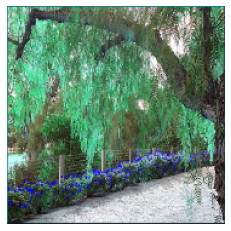

In [94]:
#Checking original 6th image
plt.axis('off')
plt.imshow(X[5])

In [95]:
# Zoom function
# In tensorflow we have different kind of data Augmentation key word for zoom(RandomZoom), RandomRotation,RandomFlip  etc

data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomZoom(-0.8),
  ]
)

**Newly generated training sample using data augmentation**

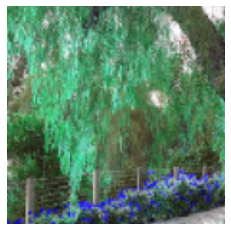

In [96]:
#For data_augmentation function, we are passing 6th image

plt.axis('off')
plt.imshow(data_augmentation(X)[5].numpy().astype("uint8"))

In [97]:
# Rotation function

data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomRotation(1)
  ]
)

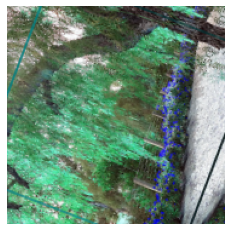

In [98]:
plt.axis('off')
plt.imshow(data_augmentation(X)[5].numpy().astype("uint8"))

# it has rotated

In [99]:
img_height = 180
img_width = 180

data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomFlip("horizontal", 
                                                 input_shape=(img_height, 
                                                              img_width,
                                                              3)),
  ]
)

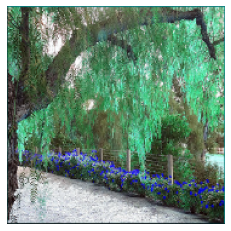

In [100]:
plt.axis('off')
plt.imshow(data_augmentation(X)[5].numpy().astype("uint8"))

# flower got flipped to left side. Original flower is on right side... Awesome...

In [101]:
# Now we combine all 3

img_height = 180
img_width = 180

data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomFlip("horizontal", 
                                                 input_shape=(img_height, 
                                                              img_width,
                                                              3)),
    layers.experimental.preprocessing.RandomRotation(0.1),
    layers.experimental.preprocessing.RandomZoom(0.1),
  ]
)

<h3 style='color:purple'>Train the model using data augmentation and a drop out layer</h3>

In [63]:
num_classes = 5

model = Sequential([
    
  data_augmentation, # here it creates data mockup based on augmentation choosen
    
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
    
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
    
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
    
  layers.Dropout(0.2), # to drop 20% of neurons in random to achieve more generalization
    
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, activation='softmax')
    
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=10)     # Can change epoch high, its taking time, so kept 10          

Epoch 1/30
86/86 [==============================] - 28s 313ms/step - loss: 1.5331 - accuracy: 0.3368
Epoch 2/30
86/86 [==============================] - 28s 330ms/step - loss: 1.1090 - accuracy: 0.5765
Epoch 3/30
86/86 [==============================] - 29s 341ms/step - loss: 0.9828 - accuracy: 0.6192
Epoch 4/30
86/86 [==============================] - 28s 328ms/step - loss: 0.9083 - accuracy: 0.6549
Epoch 5/30
86/86 [==============================] - 29s 332ms/step - loss: 0.8517 - accuracy: 0.6841
Epoch 6/30
86/86 [==============================] - 31s 358ms/step - loss: 0.7786 - accuracy: 0.7075
Epoch 7/30
86/86 [==============================] - 30s 353ms/step - loss: 0.7732 - accuracy: 0.7023
Epoch 8/30
86/86 [==============================] - 29s 336ms/step - loss: 0.7065 - accuracy: 0.7257
Epoch 9/30
86/86 [==============================] - 32s 374ms/step - loss: 0.7056 - accuracy: 0.7247
Epoch 10/30
86/86 [==============================] - 30s 353ms/step - loss: 0.6588 - accura

In [64]:
model.evaluate(X_test_scaled,y_test)

29/29 [==============================] - 3s 77ms/step - loss: 0.9256 - accuracy: 0.7342


[0.9255975484848022, 0.7342047691345215]

> You can see that by using data augmentation and drop out layer the accuracy of test set predictions is increased to 73.42% from 65%, So reduced overfitting. Train accuracy reduced from 99% to 89% but still ok overfitting reduced

In [102]:
predictions = model.predict(X_test_scaled)
predictions  # as we had used softmax above, the values are normalized between 0 and 1. 

array([[  2.429506  ,  25.09266   ,   6.4396806 , -14.958647  ,
         -2.4409065 ],
       [  9.209826  ,   2.4611855 ,  -5.1910357 ,  -5.2787447 ,
          6.584052  ],
       [  0.6022582 ,   3.9505727 ,  11.094399  ,  -5.827516  ,
          3.9550874 ],
       ...,
       [  2.1945202 ,   4.269713  ,  -4.178929  ,   8.566203  ,
          7.8911157 ],
       [  4.0852904 ,   6.266757  ,  -0.26074192,   1.0032487 ,
         -0.20179582],
       [  5.6398907 ,  -6.517675  ,   1.3576201 ,  11.257725  ,
          5.88019   ]], dtype=float32)

In [103]:
np.argmax(score) # i.e prediction flower label is 1 i.e daisy flower 

1

In [104]:
y_test[0] # in test also its daisy, so its matching. 

1

# Awesome !!!